In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sympy import symbols, expand, factor, diff, E, Function, maximum, Derivative, collect, simplify
import sympy
import sympy as sp
from scipy.integrate import quad
from scipy.stats import bernoulli



t , X_t, Y_t, dt, dW_t, dXp_t, J= symbols('t X_t Y_t dt dW_t d{X_\mathcal{P}}_t J ')
X = symbols('X')

def my_simplify(expr):
    return collect( expand(expr)
                   .subs(dW_t**2, dt)
                   .subs(dW_t*dt, 0)
                   .subs(dt**2, 0)
                   .subs(dXp_t**2,dXp_t)
                   .subs(dXp_t*dt,0)
                   .subs(dXp_t*dW_t,0) ,
                   
                   (dt,dW_t, dXp_t) )

def ito_lemma_jump(G = Function('G')(t,X_t), Θ = Function('Θ')(t,X_t), Ψ = Function('Ψ')(t, X_t), J = Function('J')(t, X_t)  ):
    G_t = diff(G, t)
    G_x = diff(G, X_t)
    G_xx = diff(G_x, X_t)
    G_j = G.subs(X_t, X_t +J ) - G  

    dG = (G_t + Θ * G_x + 0.5 * pow(Ψ,2) * G_xx )*dt + Ψ * G_x * dW_t + G_j*dXp_t
    return my_simplify(dG)


# Jump Processes



##  Poisson  Distribution:


1. Condition: 
    * Events are occuring independently
    * The probability of an events occuring in a given lenghth of time does not change over time   
1. Random Variable: 
    * Let $X$ represent the number of times the events occured in a fixed unit of time
    * We say that $X$ has a poisson distribution 
1. Properties:
    * p.m.f : $\mathbb{X}\left[X = k\right] = \lambda^k \dfrac{e^{-\lambda}}{k!} $
    * mean: :  $\mathbb{E}\left[X \right] = \lambda $
    * Variance::  $\mathbb{V}\left[X \right] = \lambda $
    * Notation :  $X \sim \mathcal{Poisson}(\lambda)$ meaning that the random variable $X$ has a poisson distribution




##   Poisson  Process:


###   Definition


A poisson process is an Integer-Valued stochastic process $\mathcal{P}(t)$ with :
* $\mathcal{P}(0) = 0$
* The increments $\mathcal{P}(t_n) - \mathcal{P}(t_{n-1})$ are independent 
* The increment have a poisson distribution:  $\mathcal{P}(s + \Delta_t) - \mathcal{P}(s) \sim \mathcal{Poisson}(\lambda \Delta_t)$ where:
    * $\lambda$ is the intensity aka number of arrival per unit of time 
    * $\Delta_t$ is the time interval of interest
* $\mathcal{P}(t)$ is the counting process that count the number of occurances over a time period t




###  Compensating Poisson  Process:


We can Define another process called the **compensating** Poison process $\overline{\mathcal{P}}(t)$ where:
* $\overline{\mathcal{P}}(t)= \mathcal{P}(t) - \lambda t$
* Note that  $\mathbb{E} \left[ d\overline{\mathcal{P}}(t)\right] = 0$
* So that the process $\overline{\mathcal{P}}(t)$ is a martingale 




###  Code to generate poisson process paths : $\mathcal{P}(t)$ 

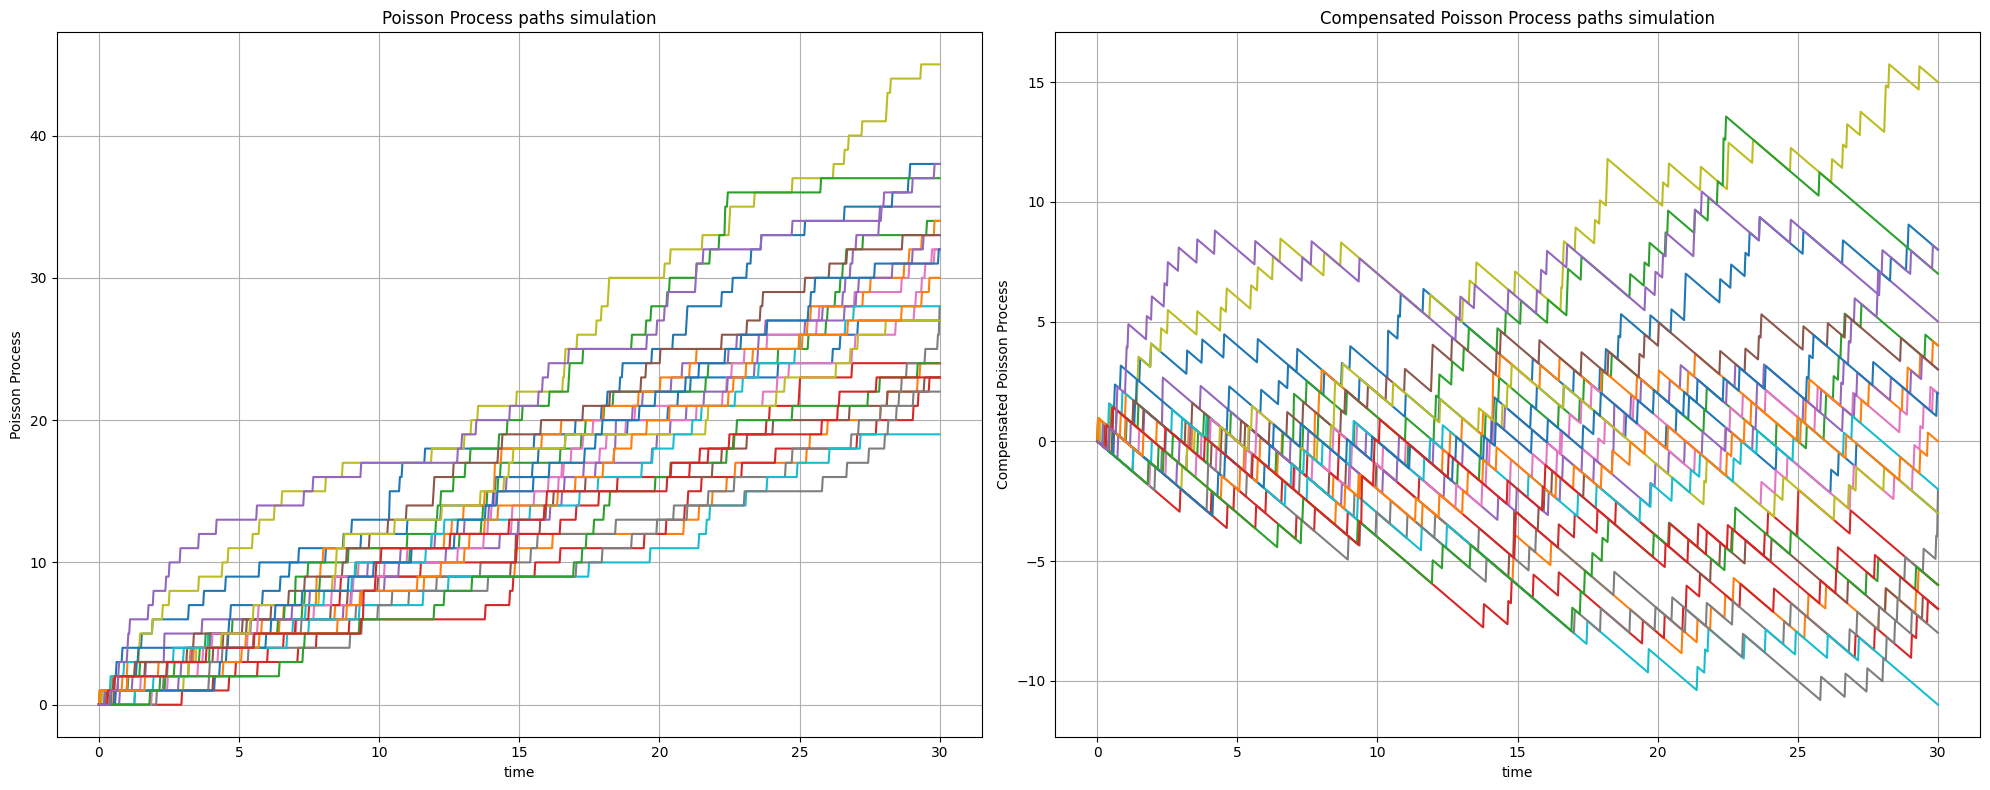

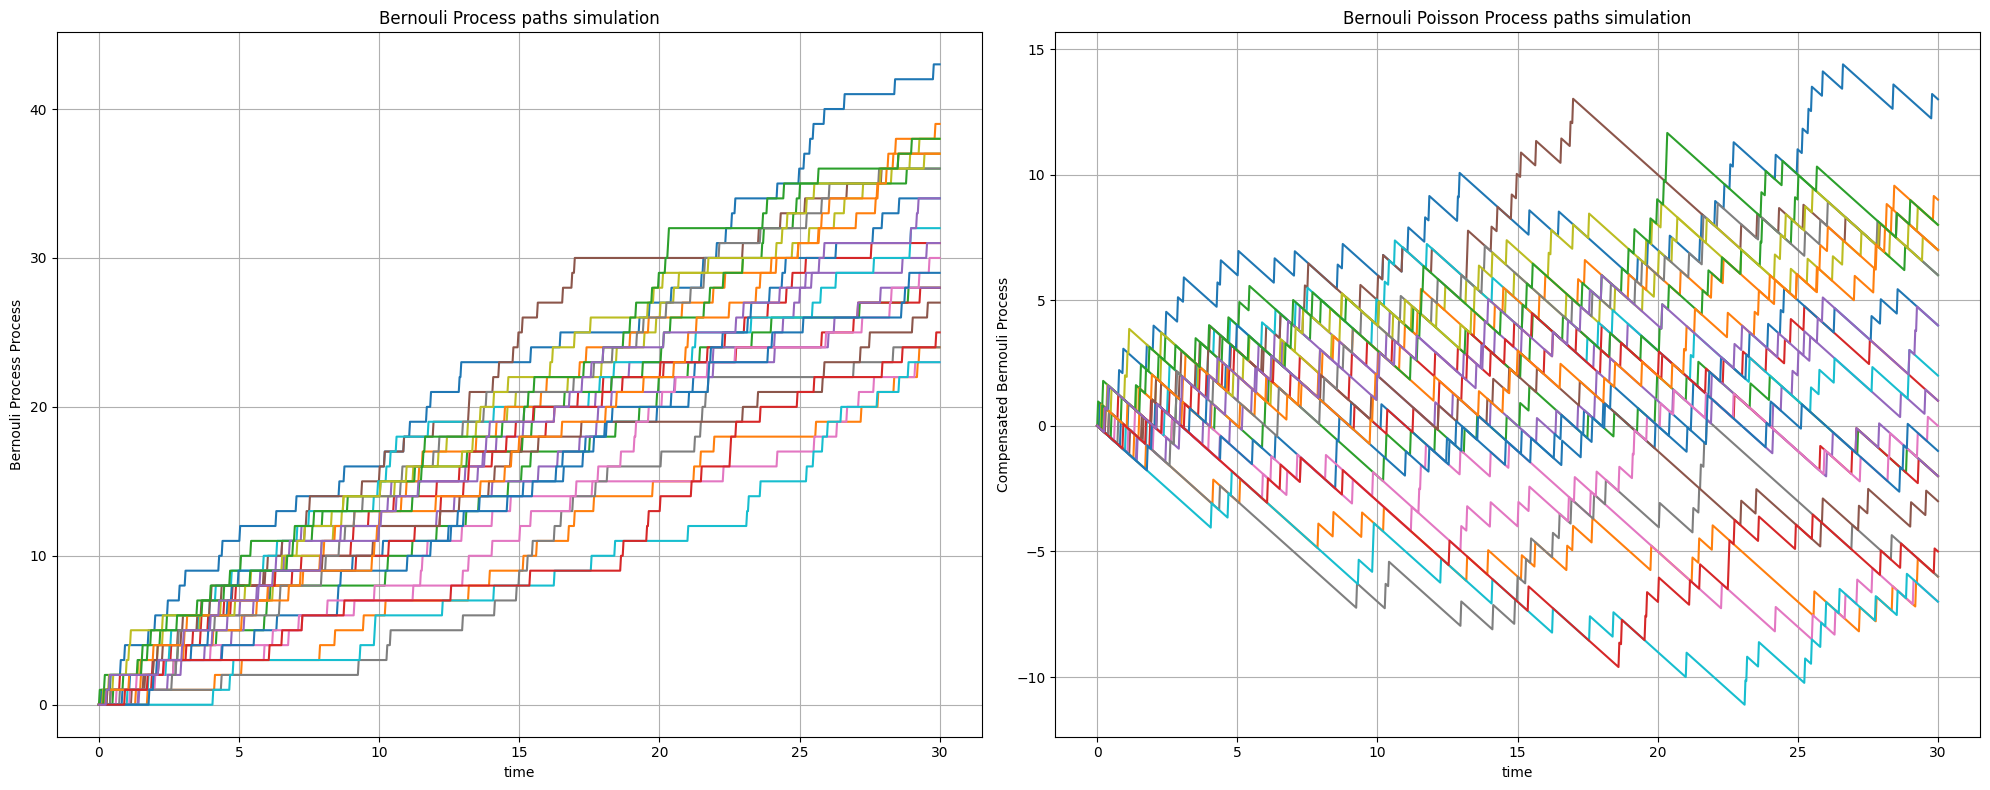

np.float64(29.834)

In [21]:
M = 1000  # number of paths
N = 1000  # number of steps
T = 30     # time horizon
λ = 1     # poisson distribution intensity

dt = T / float(N)
t = np.zeros([N+1])  # time axis which starts with t0
dP = np.random.poisson(λ*dt, [M, N])  # samples from the poisson distribution
B = np.random.binomial(n=1, p=λ*dt, size=[M, N]) # sample from bernouilli distribution
P = np.zeros([M, N+1])  # path of the poisson process
P_bernouilli  = np.zeros([M, N+1])  # path of the Bernoulli process
P_comp = np.zeros([M, N+1])  # path of the compensating poisson process
P_comp_bernouilli = np.zeros([M, N+1])  # path using bernoulli instead of poisson


for i in range(0, N):
    P[:, i+1] = P[:, i] + dP[:, i]
    P_bernouilli[:, i+1] = P_bernouilli[:, i] + B[:, i]
    
    P_comp[:, i+1] = P_comp[:, i] - λ*dt + dP[:, i]
    P_comp_bernouilli[:, i+1] = P_comp_bernouilli[:, i] - λ*dt + B[:, i]
    t[i+1] = t[i] + dt

# Create a figure with two subplots in one row
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# Plot the path of the poisson process
axs[0].plot(t, np.transpose(P[:25, :]), linestyle='-')
axs[0].grid()
axs[0].set_xlabel("time")
axs[0].set_ylabel("Poisson Process")
axs[0].set_title('Poisson Process paths simulation')

# Plot the path of the compensated poisson process
axs[1].plot(t, np.transpose(P_comp[:25, :]), linestyle='-')
axs[1].grid()
axs[1].set_xlabel("time")
axs[1].set_ylabel("Compensated Poisson Process")
axs[1].set_title('Compensated Poisson Process paths simulation')

plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()


# Create a figure with two subplots in one row
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# Plot the path of the poisson process
axs[0].plot(t, np.transpose(P_bernouilli[:25, :]), linestyle='-')
axs[0].grid()
axs[0].set_xlabel("time")
axs[0].set_ylabel("Bernouli Process Process")
axs[0].set_title('Bernouli Process paths simulation')

# Plot the path of the compensated poisson process
axs[1].plot(t, np.transpose(P_comp_bernouilli[:25, :]), linestyle='-')
axs[1].grid()
axs[1].set_xlabel("time")
axs[1].set_ylabel("Compensated Bernouli Process")
axs[1].set_title('Bernouli Poisson Process paths simulation')

plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()

# Calculate the mean of the last values of the Poisson process paths
mean_value = np.mean(P[:, -1])
mean_value

##  Jump Diffusion process


###   Jump process


Consider the SDE  $$dX(t) = J(t) d\mathcal{P}(t)$$  
we can define the _stochastic integral with respct to the poison process $\mathcal{P}(t)$_ as:
$$X(T) - X(t_0) = \int_{t_0}^{T} J(t) \,d\mathcal{P}(t) := \sum_{i=1}^{\mathcal{P}(T)} J_k  $$

$J_k$ is an i.i.d sequence of random variables with jump size propability distribution $F_J$




###   Jump diffusion process


We can extend the Black scholes model by adding a jump process to the log returns. If we let $X(t) = logS(t)$ then under the real world measure $\mathbb{P}$ we have:
$$dX_t = \mu dt +\sigma dW^{\mathbb{P}}_t + J d\mathcal{P}_t $$

* Jump-diffusion models and Levy based models are attractive because they explain well jump pattern exhibited in some stocks, or commodities specially during times of market turmoil.
* Empirical studies have shown that daily log returns have **heavy tails** and typically display **excess kurtosis**
* Including jump processes can help model heavy tails and also with parameters control the kurtosis and skewness of simulated returns. 
* This in turn could help better _fit the smile_ in the implied volatilities



###  Examples





* If we let $X_t = log(S_t)$
* Note that then $dX(t)$ is the log price change hence represent the returns of $S_t$
* And we can retrieve the original process by taking  $S_t = e^{X_t}$ 
* if we assume the log returns follows a jump diffusion process we can write

$$dX_t = \mu dt + \sigma dW^{\mathbb{P}}_t  + J d{\mathcal{P}}_t $$



####  Find the dynamics of  $S_t$ 


To find the dynamics of $S_t$ we use ito lemma to find the dinamics of $F(t,X(t)) = e^{X(t)}$

In [3]:
t , X_t, Y_t, dt, dW_t, dXp_t, J, μ, σ= symbols('t X_t Y_t dt dW_t d{\mathcal{P}}_t J μ, σ')
S_t = symbols('S_t')
μ, σ, Δ_t, r, M_t = symbols('μ σ Δ_t r M_t')

dM_t = r*M_t*dt


# Define the dynamics of dX_t
θ = μ
Ψ = σ
dX_t = θ*dt + Ψ*dW_t + J*dXp_t

# Find the dynamics of F
F = E**X_t
dF = ito_lemma_jump(G=F , Θ=θ , Ψ=Ψ, J = J)
print("the dynamic of dF :")
display(dF)

the dynamic of dF :


dW_t*σ*exp(X_t) + dt*(μ*exp(X_t) + 0.5*σ**2*exp(X_t)) + d{\mathcal{P}}_t*(exp(J)*exp(X_t) - exp(X_t))

Now since
$$dF = \left(μ e^{X_{t}}dt +   0.5 σ^{2} e^{X_{t}}\right)dt+ σ e^{X_{t}} dW^{\mathbb{P}}_{t}  +   \left(e^{J} e^{X_{t}} - e^{X_{t}}\right)d{\mathcal{P}}_t $$

Now since  $X(t) = logS(t)$ let's subsititute $X_t$  

In [4]:

# now substitute X_t for log(S_t)
dS_t = dF.subs(X_t, sympy.ln(S_t))
print("the dynamic of dS_t :")
display(dS_t)

the dynamic of dS_t :


S_t*dW_t*σ + dt*(S_t*μ + 0.5*S_t*σ**2) + d{\mathcal{P}}_t*(S_t*exp(J) - S_t)

The intermediary steps to the sympy calculations are
$$
\begin{align}
dF &= d\left( e^{X(t)} \right) \\
    &= d\left( e^{log S(t)} \right) \\
    &= dS_t \\
  &=\left(μ e^{log S(t)}dt +   0.5 σ^{2} e^{log S(t)}\right)dt+ σ e^{log S(t)} dW^{\mathbb{P}}_{t}  +  \left(e^{J} e^{log S(t)} - e^{log S(t)}\right) d{\mathcal{P}}_t\\
  &= \left( μ + \frac{1}{2}  σ^{2}\right)S_{t}dt  + σS_{t} dW^{\mathbb{P}}_{t}  + \left( e^{J} - 1\right)S_{t} d{X_\mathcal{P}}_t
\end{align}
$$

 ### Find the Process of the discounted Stock price $G(t, S_t, M_t) = \dfrac{S_t}{M_t}$  


here we need to apply ito the quotient rule since we know the dynamics of both $S_t$ and $M_t$

In [5]:
G = S_t/M_t
dG = (M_t *dS_t - S_t*dM_t)/pow(M_t,2)
print ('The dynamics of discounted stock price is: ')
my_simplify(dG)

The dynamics of discounted stock price is: 


dt*(-S_t*r/M_t + S_t*μ/M_t + 0.5*S_t*σ**2/M_t) + d{\mathcal{P}}_t*(S_t*exp(J)/M_t - S_t/M_t) + S_t*dW_t*σ/M_t

#### What is the dynamic under $\mathbb{Q}$




The dynamic of the discounted stock process should be a martingale under $\mathbb{Q}$. Hence drift should be zero under $\mathbb{P}$.

To find the dynamics under The risk neutral measure $\mathbb{Q}$ our strategy is:
1. Compute the drift a.k.a expected value of the discounted stock process under $\mathbb{P}$
2. Then we find under what condition of $\mu$ the drift would be equal to zero
3. This will give us the relation between $\mathbb{Q}$ and $\mathbb{P}$
 

Let's compute the drift of the discounted stock process under $\mathbb{P}$
$$
\begin{align}
\mathbb{E}[d\dfrac{S_t}{M_t}]  &= \mathbb{E}\left[ \displaystyle dt \left(- \frac{S_{t} r}{M_{t}} + \frac{S_{t} μ}{M_{t}} + \frac{0.5 S_{t} σ^{2}}{M_{t}}\right) + d{X_\mathcal{P}}_t \left(\frac{S_{t} e^{j}}{M_{t}} - \frac{S_{t}}{M_{t}}\right) + \frac{S_{t} dW^{\mathbb{P}}_{t} σ}{M_{t}}  \right] \\
&= \mathbb{E}\left[ dt \left(- \frac{S_{t} r}{M_{t}} + \frac{S_{t} μ}{M_{t}} + \frac{0.5 S_{t} σ^{2}}{M_{t}}\right)\right] +  \mathbb{E}\left[ d{X_\mathcal{P}}_t \left(\frac{S_{t} e^{j}}{M_{t}} - \frac{S_{t}}{M_{t}}\right)\right] + \mathbb{E}\left[ \frac{S_{t} dW^{\mathbb{P}}_{t} σ}{M_{t}} \right]\\
&= \mathbb{E}\left[  \left(- \frac{S_{t} r}{M_{t}} + \frac{S_{t} μ}{M_{t}} + \frac{0.5 S_{t} σ^{2}}{M_{t}}\right)\right]dt +    \mathbb{E}\left[\frac{S_{t} e^{j}}{M_{t}} - \frac{S_{t}}{M_{t}}\right]\times \mathbb{E}\left[ d{X_\mathcal{P}}_t \right] + 0\\
&= (μ - r +0.5σ^{2} )\mathbb{E}\left[   \frac{S_{t} }{M_{t}} \right]dt +  \mathbb{E}\left[ (e^{j} -1)  \frac{S_{t} }{M_{t}} \right]\lambda dt\\
&= (μ - r +0.5σ^{2} )\mathbb{E}\left[   \frac{S_{t} }{M_{t}} \right]dt +  \lambda\mathbb{E}\left[ (e^{j} -1)\right] \mathbb{E}\left[  \frac{S_{t} }{M_{t}} \right] dt\\
&=\left( μ - r +0.5σ^{2} + \lambda\mathbb{E}\left[ e^{j} -1\right] \right)\mathbb{E}\left[  \frac{S_{t} }{M_{t}} \right] dt
\end{align}
$$

Hence for the process to be driftless under $\mathbb{Q}$ we must have  
$$\mu = r - 0.5σ^{2} - \lambda\mathbb{E}\left[ e^{j} -1\right]$$

Replacing $\mu$ definition of $dX_t$ the process we arrive at

$$
\begin{align}
dX_t = \mu dt + \sigma dW^{\mathbb{P}}_t  + j d{X_\mathcal{P}}_t
     = \left(r - 0.5σ^{2} - \lambda\mathbb{E}\left[ e^{j} -1\right]\right)dt + \sigma dW^{\mathbb{Q}}_t + j d{X_\mathcal{P}}_t
\end{align}
$$



For $S_t$ hence we have 
$$
dS_t=\left( μ + \frac{1}{2}  σ^{2}\right)S_{t}dt  + σS_{t} dW^{\mathbb{P}}_{t}  + \left( e^{j} - 1\right)S_{t} d{X_\mathcal{P}}_t = \left(r - \lambda\mathbb{E}\left[ e^{j} -1\right]\right)dt + σS_{t} dW^{\mathbb{Q}}_{t}  + \left( e^{j} - 1\right)S_{t} d{X_\mathcal{P}}_t
$$

## Code to generate Merton paths with jumps

The log price change of the stock follows : $ d\left(log(S_t)\right) = dX_t = \mu dt +\sigma dW^{\mathbb{P}}_t + J dX_\mathcal{P}$  
So $S(t) = e^{X(t)}$

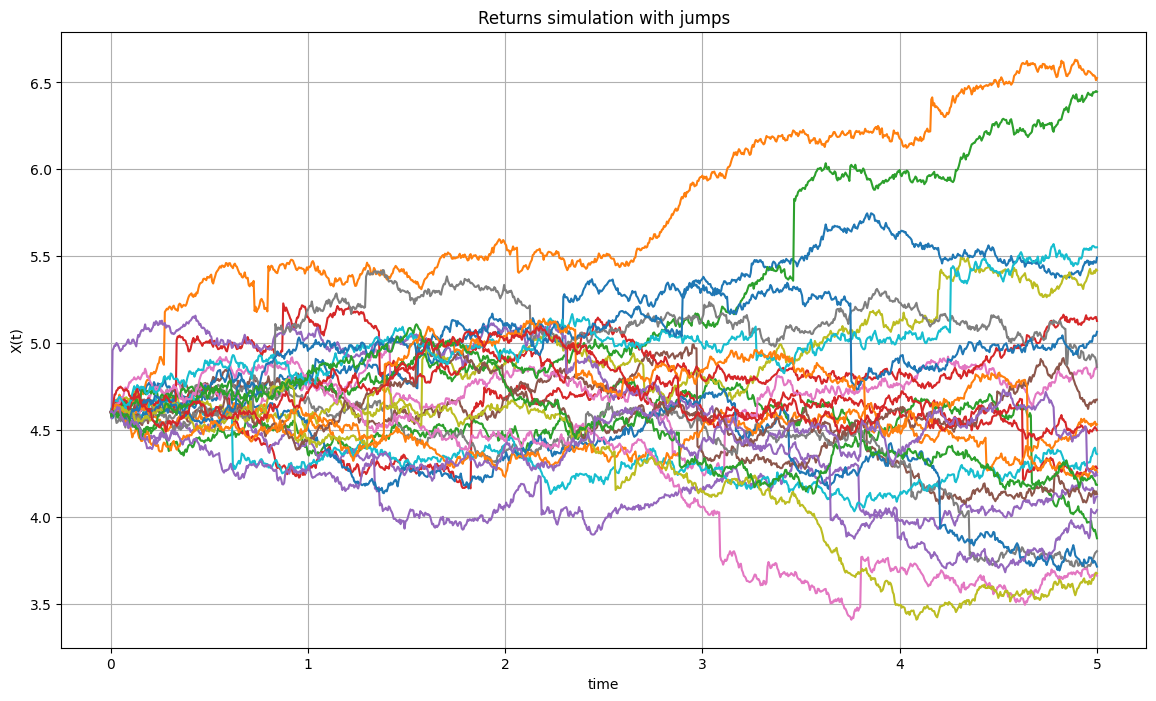

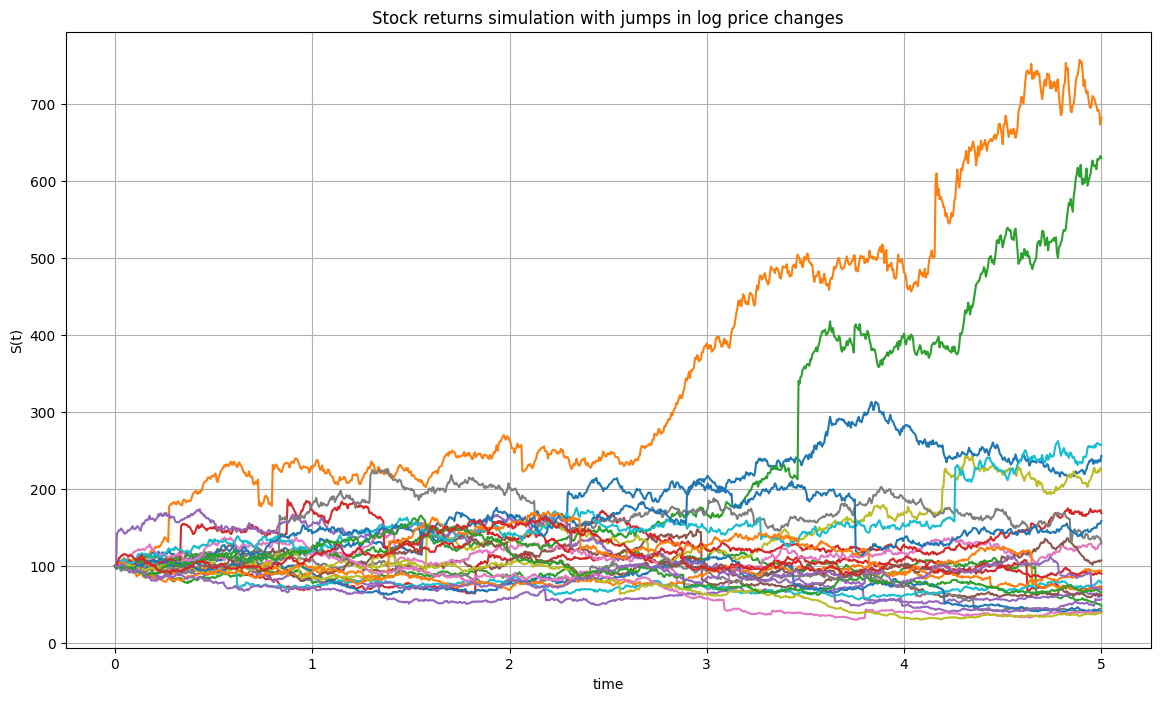

In [9]:
M = 100 # number of paths 
N = 1000  # number of steps
T = 5   # time horizon
λ = 1 # poisson distribution intensity

S0 = 100

μ_J = 0
σ_J = 0.2

r = 0.05
σ = 0.2

# we assume that J ~ N(μ_J,σ_J ) so e^J ~ Log N (μ_J,σ_J )
Eej = np.exp(μ_J + 0.5*σ_J**2)


dt = T / float(N)
t = np.zeros([N+1]) # time axis which starts with to
Zpois = np.random.poisson(λ*dt, [M,N]) # samples from the poisson distribution
Zber = np.random.ber
Z = np.random.normal(0,1,[M,N]) # samples from the random distribution]
J = np.random.normal(μ_J,σ_J,[M,N])

X = np.zeros([M, N+1]) # path of the returns process
S = np.zeros([M, N+1]) # path of the Stock process

X[:,0] = np.log(S0)
S[:,0] = S0

for i in range(0,N):
    X[:,i+1] = X[:,i] + (r - λ*(Eej-1) - 0.5*σ**2)*dt + σ*Z[:,i]*np.sqrt(dt) + J[:, i]*Zpois[:,i]
    t[i+1] = t[i] + dt

S = np.exp(X)

# plot the path of the poisson process
fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(t, np.transpose(X[:25,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("X(t)");
ax.set_title('Returns simulation with jumps');

# plot the path of the compensaed poisson process
fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(t, np.transpose(S[:25,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("S(t)");
ax.set_title('Stock returns simulation with jumps in log price changes');